In [ ]:
from model import Seq2SeqTransformer, FeatureExtractor
import torch
import torch.nn as nn
import torch.optim as optim
from dataloader import DocLayNetDataset
import random

N = 20
num_classes = 11

# set TOKENIZERS_PARALLELISM=false to avoid warnings
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

dataset = DocLayNetDataset(split="test", rewrite_storage=False)
feature_extractor = FeatureExtractor(dataset)
pages_features, pages_targets = feature_extractor.get_page_features()


features_and_targets = list(zip(pages_features, pages_targets))

random.shuffle(features_and_targets)
total = len(features_and_targets)
training_data = features_and_targets[:int(0.8 * total)]
validation_data = features_and_targets[int(0.8 * total):]
print(f"Training samples: {len(training_data)}, Validation samples: {len(validation_data)}")

/Users/shenjiajun/miniconda3/envs/ml2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 4999/4999 [06:35<00:00, 12.63it/s]

Training samples: 3386, Validation samples: 847


In [ ]:
import importlib

import model as model_module
from model import Seq2SeqTransformer

model = Seq2SeqTransformer(input_dim=N, output_dim=num_classes, num_layers=4, num_heads=8, hidden_dim=512).to('mps')
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=-1).to('mps')
model

/Users/shenjiajun/miniconda3/envs/ml2/lib/python3.11/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Seq2SeqTransformer(
  (input_proj): Linear(in_features=6, out_features=512, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
        )
        (linear1): Linear(in_features=512, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=512, bias=True)
        (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_proj): Linear(in_features=512, out_features=11, bias=True)
)

 12%|█▏        | 49/424 [00:25<27:20,  4.37s/it]

Iteration 385 | Validation Accuracy = 0.5299


 24%|██▎       | 100/424 [00:40<04:30,  1.20it/s]

Iteration 785 | Validation Accuracy = 0.3847


 35%|███▌      | 149/424 [00:58<03:39,  1.25it/s]

...

Iteration 2785 | Validation Accuracy = 0.5051


 94%|█████████▍| 399/424 [02:14<00:19,  1.27it/s]

Iteration 3185 | Validation Accuracy = 0.5382


100%|██████████| 424/424 [02:20<00:00,  3.01it/s]


Epoch 0 | Loss = 1.0475, Accuracy = 0.5382


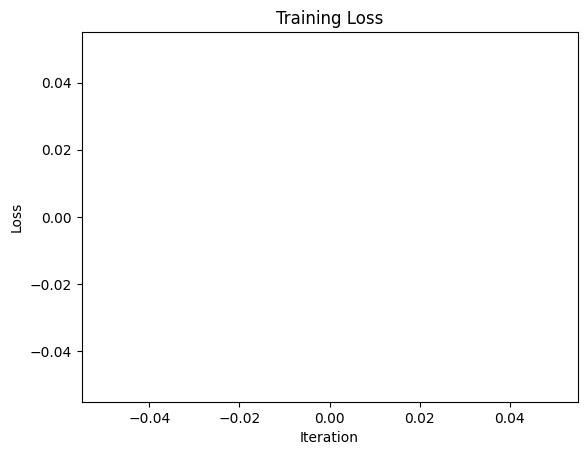

In [ ]:
from tqdm import tqdm
from model import collate_batch
BATCH_SIZE = 8
EPOCHS = 1
losses = []
accuracies = []
model = model

for epoch in range(EPOCHS):
    j = 0
    for i in tqdm(range(0, len(training_data), BATCH_SIZE)):
        j+=1
        batch_data = training_data[i:i+BATCH_SIZE]
        
        x, y, lengths = collate_batch(batch_data, N)
        x, y = x.to('mps'), y.to('mps')
        optimizer.zero_grad()
        pred = model(x)  # (batch_size, M, num_classes)
        
        pred_flat = pred.view(-1, num_classes)  # (batch_size * M, num_classes)
        y_flat = y.view(-1)  # (batch_size * M)
        
        loss = criterion(pred_flat, y_flat).to('mps')
        losses.append(loss.item())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        # accuracy
        if (j + 1) % 50 == 0:
            total = 0
            correct = 0
            for page_features_val, targets_val in validation_data[:100]:
                x_val = torch.tensor(page_features_val, dtype=torch.float32).reshape(N, -1).to('mps')
                y_val = torch.tensor(targets_val, dtype=torch.long).to('mps')
                with torch.no_grad():
                    pred_val = model(x_val)
                    _, predicted_val = torch.max(pred_val, dim=1)
                    correct_val = (predicted_val == y_val).sum().item()
                    total += y_val.size(0)
                    correct += correct_val
            accuracy = correct / total

            print(f"Iteration {i+1} | Validation Accuracy = {accuracy:.4f}")
    print(f"Epoch {epoch} | Loss = {loss.item():.4f}, Accuracy = {accuracy:.4f}")


# Ignore, loss is empty plot
import matplotlib.pyplot as plt

context_size = 50
smoothed_losses = []
for i in range(len(losses), context_size):
    smoothed_losses.append(sum(losses[i - context_size:i]) / context_size)
    
plt.plot(smoothed_losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [5]:
model

Seq2SeqTransformer(
  (input_proj): Linear(in_features=6, out_features=512, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
        )
        (linear1): Linear(in_features=512, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=512, bias=True)
        (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_proj): Linear(in_features=512, out_features=11, bias=True)
)

In [6]:
def visualize_tokens(pdf_features, pdf_path, output_path: str, labels: bool = False):
    from reportlab.pdfgen import canvas
    from PyPDF2 import PdfReader, PdfWriter
    import io
    pages = pdf_features.pages
    first_page = pages[0]
    tokens = first_page.tokens

    reader = PdfReader(pdf_path)
    writer = PdfWriter()
    page = reader.pages[0]
    packet = io.BytesIO()
    width, height = page.mediabox.width, page.mediabox.height
    width, height = float(width), float(height)
    can = canvas.Canvas(packet, pagesize=(width, height))
    for token in tokens:
        bounding_box = token.bounding_box
        l, t, r, b = bounding_box.left, bounding_box.top, bounding_box.right, bounding_box.bottom
        x, y, w, h = l, height - t, r - l, t - b
        token_type = token.token_type


        can.rect(x, y, w, h, stroke=1, fill=0)
        can.drawString(x, y + h + 5, str(token_type))
    can.save()
    packet.seek(0)

    overlay_pdf = PdfReader(packet)
    page.merge_page(overlay_pdf.pages[0])
    writer.add_page(page)

    with open(output_path, "wb") as f_out:
        writer.write(f_out)

In [43]:


from dataloader import ModifiedPdfFeatures
test_pdf = "test_pdfs/DEVOLOPMENT_OF_AN_ALGORITHM_TO_DETERMINATE_THE_ORIENTATION_USING_AN_IMU.pdf"
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
pdf_features = ModifiedPdfFeatures.from_pdf_path(test_pdf)
page = pdf_features.pages[0]
max_length = 14

targets = []
feature_rows = []
for token in page.tokens:
    # token ids, padding to max length
    content = token.content
    encoding = tokenizer(content, add_special_tokens=True, return_tensors="pt")
    token_ids = encoding["input_ids"][0].tolist()
    if len(token_ids) < max_length:
        padding_length = max_length - len(token_ids)
        token_ids += [tokenizer.pad_token_id] * padding_length
    else:
        token_ids = token_ids[:max_length]
    
    # font info
    font_id = float(token.font.font_id)
    font_size = float(token.font.font_size)
    font_features = [font_id, font_size]

    # position info
    box = token.bounding_box
    positions = [box.left, box.top, box.right, box.bottom]

    features = token_ids + font_features + positions
    feature_rows.append(features)
    targets.append(token.token_type.get_index())

feature_rows = torch.tensor(feature_rows, dtype=torch.float32).reshape(N, -1).to('mps')

model.eval()
with torch.no_grad():
    predictions = model(feature_rows)
    _, predicted_labels = torch.max(predictions, dim=1)
print("Predicted labels:", predicted_labels.tolist())

visualize_tokens(pdf_features, test_pdf, "output.pdf", labels=True)


Predicted labels: [6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6]


In [7]:
def compute_confusion_matrix(model, validation_data, num_classes, N):
    import numpy as np

    confusion_matrix = np.zeros((num_classes, num_classes), dtype=int)

    model.eval()
    with torch.no_grad():
        for page_features_val, targets_val in tqdm(validation_data):
            x_val = torch.tensor(page_features_val, dtype=torch.float32).reshape(N, -1).to('mps')
            y_val = torch.tensor(targets_val, dtype=torch.long).to('mps')
            
            pred_val = model(x_val)
            _, predicted_val = torch.max(pred_val, dim=1)
            
            for true_label, pred_label in zip(y_val.tolist(), predicted_val.tolist()):
                confusion_matrix[true_label][pred_label] += 1

    return confusion_matrix

    """
    print("各类别指标:")
    print(f"{'类别':<8} {'准确率':<10} {'召回率':<10} {'F1分数':<10} {'样本数':<8}")
    print("-" * 50)

    for i in range(num_classes):
        # True Positives
        tp = confusion_matrix[i][i]
        # False Positives
        fp = confusion_matrix[:, i].sum() - tp
        # False Negatives
        fn = confusion_matrix[i, :].sum() - tp
        # True Negatives
        tn = confusion_matrix.sum() - tp - fp - fn
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        support = confusion_matrix[i, :].sum()
        
        print(f"{i:<8} {precision:<10.4f} {recall:<10.4f} {f1:<10.4f} {support:<8}")

    total_correct = np.trace(confusion_matrix)
    total_samples = confusion_matrix.sum()
    overall_accuracy = total_correct / total_samples if total_samples > 0 else 0
    print("-" * 50)
    print(f"总体准确率: {overall_accuracy:.4f}")
    print(f"总样本数: {total_samples}")"""


100%|██████████| 847/847 [01:20<00:00, 10.59it/s]
/var/folders/79/ph0ylc_17ml8rtdwz_53k51r0000gn/T/ipykernel_98831/2471475952.py:27: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/79/ph0ylc_17ml8rtdwz_53k51r0000gn/T/ipykernel_98831/2471475952.py:27: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/79/ph0ylc_17ml8rtdwz_53k51r0000gn/T/ipykernel_98831/2471475952.py:27: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/79/ph0ylc_17ml8rtdwz_53k51r0000gn/T/ipykernel_98831/2471475952.py:27: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/79/ph0ylc_17ml8rtdwz_53k51r0000gn/T/ipykernel_98831/2471475952.py:27: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) Deja

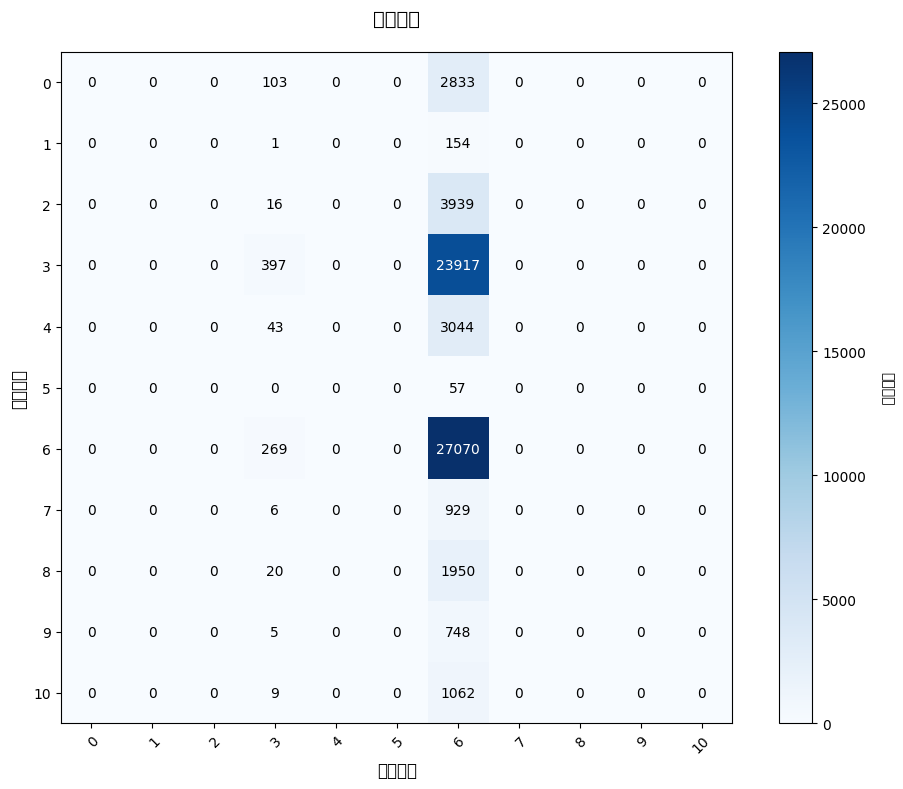

In [9]:
def plot_confusion_matrix(confusion_matrix, num_classes):
    import numpy as np
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(confusion_matrix, cmap='Blues')

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('样本数量', rotation=270, labelpad=20)

    ax.set_xticks(np.arange(num_classes))
    ax.set_yticks(np.arange(num_classes))
    ax.set_xticklabels(range(num_classes))
    ax.set_yticklabels(range(num_classes))

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    for i in range(num_classes):
        for j in range(num_classes):
            text = ax.text(j, i, confusion_matrix[i, j],
                        ha="center", va="center", 
                        color="white" if confusion_matrix[i, j] > confusion_matrix.max()/2 else "black")

    ax.set_title("混淆矩阵", fontsize=14, pad=20)
    ax.set_ylabel('真实标签', fontsize=12)
    ax.set_xlabel('预测标签', fontsize=12)
    plt.tight_layout()
    plt.show()

m = compute_confusion_matrix(model=model, validation_data=validation_data, num_classes=num_classes, N =6)
plot_confusion_matrix(m,num_classes)